# Setup & Imports

In this notebook we present the training and evaluation of a Logistic Regression model on the preprocessed dataset of tennis matches, described previously in `src/notebooks/preprocessing.ipynb`. 

The document is structured as follows:
- **Setup & Imports**: we import the necessary libraries and modules, and build the preprocessing pipeline.
- **Training & Fine-tuning**: we train the model and perform hyperparameter tuning
- **Evaluation**: we evaluate the model on the test set and analyze the results.

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd

PROJECT_ROOT = Path.cwd().parent 
sys.path.append(str(PROJECT_ROOT))

from typing import cast

from src.data.loader import load_data, train_test_split
from src.data.preprocess import preprocessing_pipeline, create_labels
from src.data.transformers import DropFeatureSelector
from src.features.features import feature_engineering_pipeline
from src.training.training import training_pipeline, fine_tune, feature_selection_pipeline
from src.evaluation.metrics import feature_importance, cross_validation, evaluation_metrics, print_metrics
from src.evaluation.plots import plot_feature_importance, plot_roc_curve, plot_confusion_matrix
from src.utils.utils import get_best_estimator, TSCV

from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

In [2]:
df = load_data()
create_labels(df)
X_train, X_test, y_train, y_test = train_test_split(df)
prep_pipeline : Pipeline = preprocessing_pipeline(X_train, y_train)
feat_pipeline : Pipeline = feature_engineering_pipeline()

preprocessor = Pipeline(
    steps=[
        ("preprocessing", prep_pipeline),
        ("feature_engineering", feat_pipeline),
        ("standard_scaler", StandardScaler())
    ]
)

# Training & Fine Tuning

Firstly, we add the Logistic Regression Classifier as a step for the pipeline, then the we perform the fine tuning of the hyperparameters using a `RandomizedSearchCV` with 5-fold.  

In [ ]:
log_reg_train_pipeline = training_pipeline(model=LogisticRegression(random_state=42))

pipeline = Pipeline(
        steps = preprocessor.steps + log_reg_train_pipeline.steps
    )

hyperparams = [
    {
        "training__solver": ["liblinear"],
        "training__C": [0.001, 0.01, 0.1, 1, 10, 100],
        "training__l1_ratio": [0, 1],    
        "training__class_weight": [None, "balanced"],
        "training__max_iter": [500, 1000, 2000],
    },
    {
        "training__solver": ["saga"],
        "training__C": [0.001, 0.01, 0.1, 1, 10, 100],
        "training__l1_ratio": [0, 1],    
        "training__class_weight": [None, "balanced"],
        "training__max_iter": [500, 1000, 2000],
    },
]

search_log_reg = fine_tune(
    pipeline=pipeline,
    tuning_methods=RandomizedSearchCV,
    tscv=TSCV,
    hyperparams=hyperparams,
    scoring="accuracy",
    random_state=42,
    verbose=0,
)

search_log_reg.fit(X_train, y_train)

We derive the best estimator from the search, and we validate the model using cross-validation on the training set.

In [5]:
best_estimator = get_best_estimator(search_log_reg)

cross_val_scores = cross_validation(
        pipeline=best_estimator,
        X=X_train,
        y=y_train,
        tscv=TSCV,
        verbose=0,
        scoring="accuracy"
    )

print(pd.Series(cross_val_scores).describe())

count    5.000000
mean     0.671090
std      0.012416
min      0.651997
25%      0.668585
50%      0.670616
75%      0.681110
max      0.683142
dtype: float64


The classifier demonstrated moderate classification performance, achieving an average accuracy of around 67% across five cross-validation folds. 
Its low standard deviation suggests that the model's performance is stable and relatively insensitive to the particular dataset on which it was trained.

## Feature Selection

The feature set generated after preprocessing contains many columns, some of which are redundant or weakly related to the target outcome. Thus, we can perform feature selection before the final Logistic Regression training, to improve generalization on unseen matches, reducing the noise and model complexity. 
Moreover, this method helps identify which tennis statistics are most informative for predicting the winner.

Initially, we extract the feature importance scores from the tuned Logistic Regression model. 

In [6]:
importances = feature_importance(
    pipeline=best_estimator,
    X=X_train,
    model_step="training",
    coef=True
)

importances

,importance
last_k_games_win_rate_diff,0.097668
Tournament_US Open,0.060121
pts_diff,0.051379
sets_h2h_diff,0.047327
Tournament_French Open,0.042076
...,...
rank_diff,-0.075208
weighted_pts_diff,-0.102728
series,-0.126466
avg_bet_diff,-0.350400


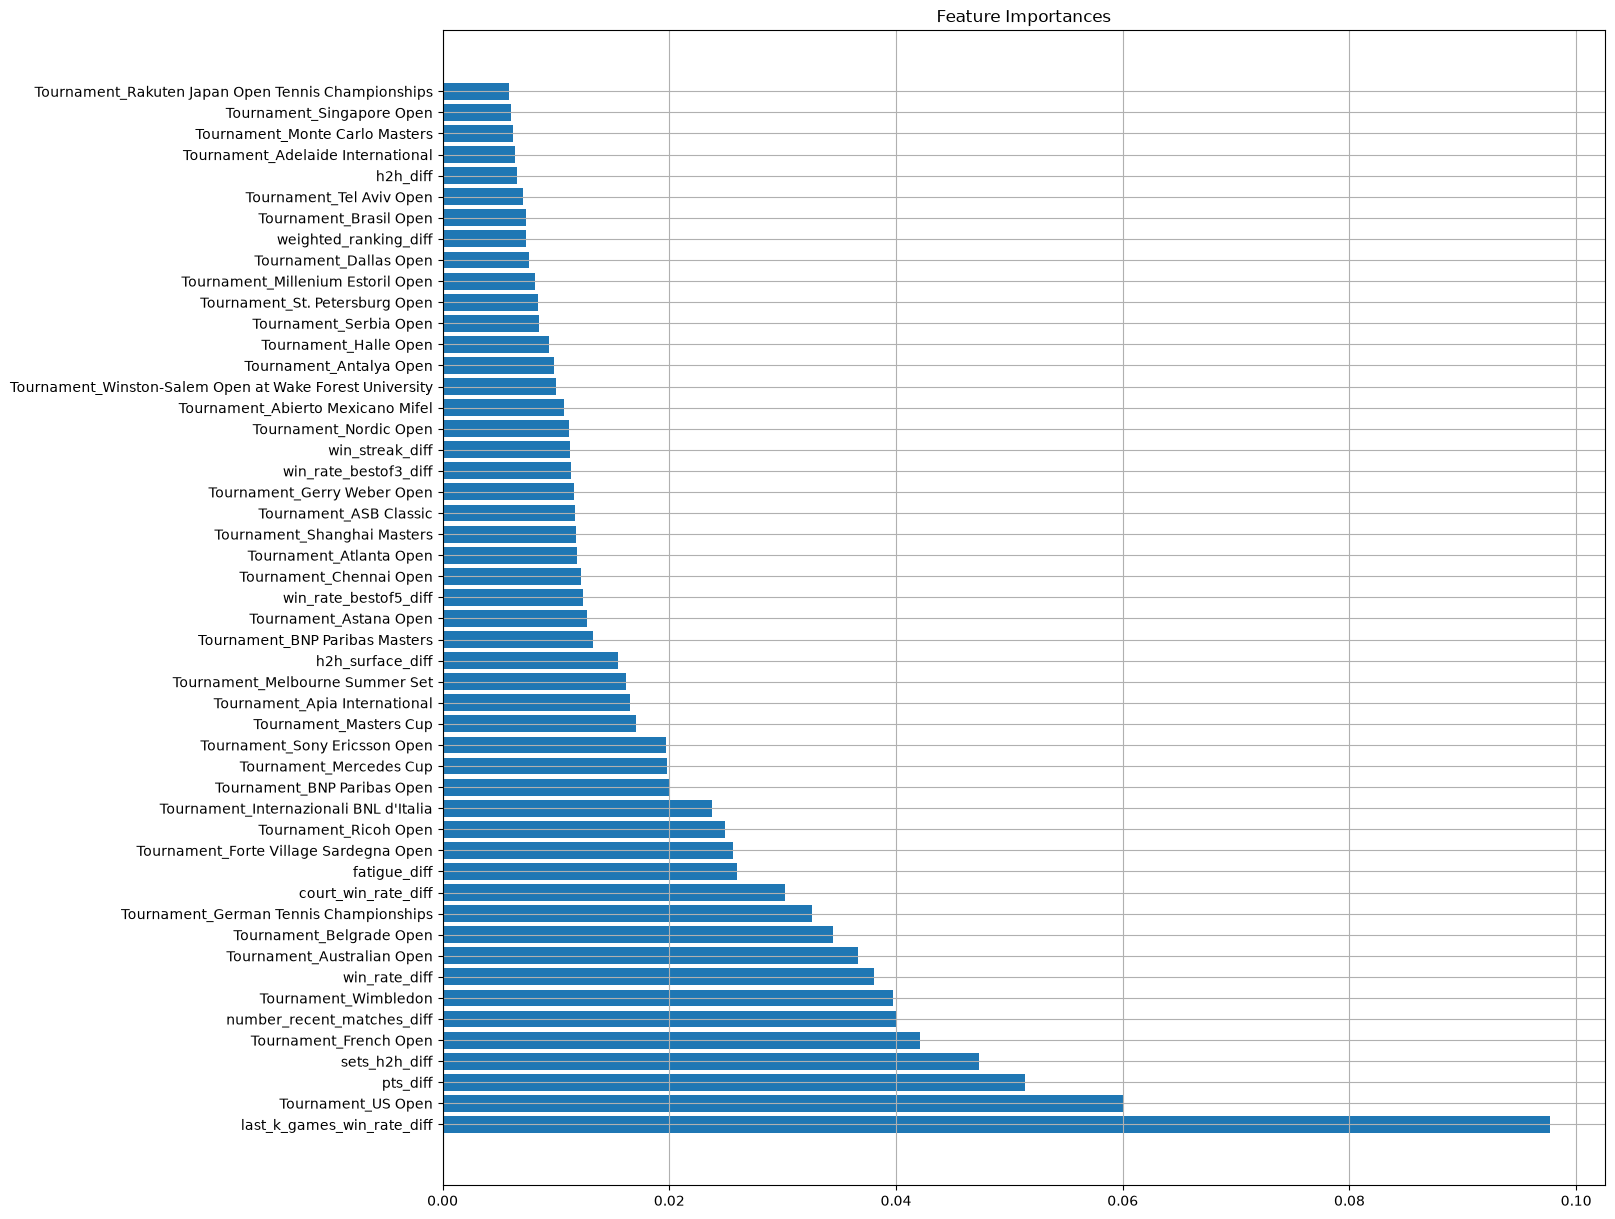

In [7]:
plot_feature_importance(
    feature_names=importances.index.tolist(),
    feature_importances=importances["importance"],
    top_n=50
)

The feature importance scores cleary show that the tournaments ohe columns are very relevant for the model. Therefore we can try to simplify the model by performing `RFECV` (`Recursive Feature Elimination with Cross-Validation`) to find the best subset of features for describing the target variable.

In [ ]:
rcevf_pipeline = feature_selection_pipeline(
    model=LogisticRegression(random_state=42),
    tscv=TSCV,
    min_features_to_select=20,
)

pipeline = Pipeline(
    steps= preprocessor.steps + [
                ("fs", rcevf_pipeline),
            ] + log_reg_train_pipeline.steps
    )

search_rf = fine_tune(
    pipeline=pipeline,
    tuning_methods=RandomizedSearchCV,
    tscv=TSCV,
    hyperparams=hyperparams,
    scoring="accuracy",
    verbose=0,
    random_state=42
)

search_rf.fit(X_train, y_train)

In [9]:
best_estimator = get_best_estimator(search_rf)

cross_val_scores = cross_validation(
        pipeline=best_estimator,
        X=X_train,
        y=y_train,
        tscv=TSCV,
        verbose=0,
        scoring="accuracy"
    )

print(pd.Series(cross_val_scores).describe())

count    5.000000
mean     0.672918
std      0.011991
min      0.653690
25%      0.670278
50%      0.676032
75%      0.679756
max      0.684834
dtype: float64


The accuracy of the model obtained with cross-validation is similar to the previous one, thus we can choose the model with less features.

Therefore, for evaluation we will use the best estimator obtained from the feature selection pipeline, so we define the full pipeline as follows:

In [10]:
full_pipeline_lr = best_estimator

# Evaluation

We evaluate the full pipeline on the test set.

In [11]:
y_pred = full_pipeline_lr.predict(X_test)

In [12]:
metrics : dict = evaluation_metrics(
    model=full_pipeline_lr,
    X_test=X_test,
    y_test=y_test,
    y_pred=y_pred
)

print_metrics(metrics)


Accuracy:
0.6812

Roc Auc:
0.7390

F1:
0.6781

Recall:
0.6901

Confusion Matrix:
      0     1
0  1542   750
1   673  1499


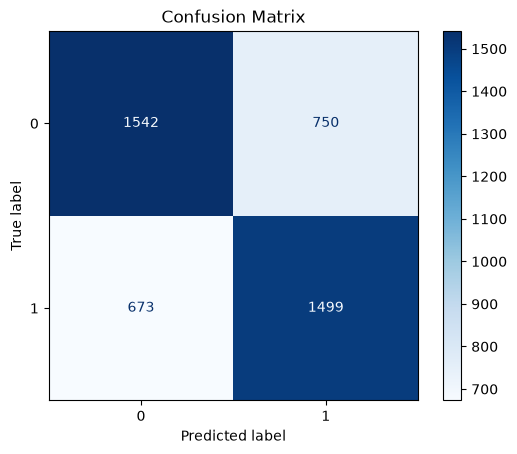

In [13]:
plot_confusion_matrix(cm=metrics["confusion_matrix"])

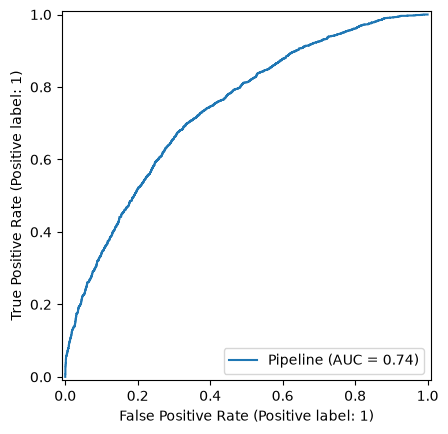

In [14]:
plot_roc_curve(
    model=full_pipeline_lr,
    X_test=X_test,
    y_test=y_test
)

Recall that the task is a binary classification problem with two players, thus, the goal of the model should be to predict correctly the most amount of matches outcome.
Therefore the main metrics to evaluate the generalization of the model are accuracy and roc-auc:
- The accuracy of the model on unseen matches is nearly 68%, which is similar to the accuracy obtained during validation.
- The roc-auc score obtained reached roughly 0.74.
- The confusion matrix shows that the model does not favor any player, since the difference between the number of false positives and false negatives is not significant.

In conclusion, we investigate the distribution of wrongly predicted matches.

In [15]:
wrong = np.asarray(y_pred) != np.asarray(y_test)
X_test_transformed = full_pipeline_lr[:-1].transform(X_test)
errors = X_test_transformed.loc[wrong].copy()
errors["y_true"] = np.asarray(y_test)[wrong]
errors["y_pred"] = np.asarray(y_pred)[wrong]
# errors["proba_pos"] = full_pipeline_rf.predict_proba(X_test)[:, 1]

# false positives vs false negatives
fp = errors[(errors.y_true == 0) & (errors.y_pred == 1)] # player_2 actually won
fn = errors[(errors.y_true == 1) & (errors.y_pred == 0)] # player_1 actually won

fp.describe().transpose()

,count,mean,std,min,25%,50%,75%,max
Tournament_Adelaide International 1,750.0,-0.057292,1.388705e-17,-0.057292,-0.057292,-0.057292,-0.057292,-0.057292
Tournament_Belgrade Open,750.0,0.449461,3.539104e+00,-0.038324,-0.038324,-0.038324,-0.038324,26.093029
Tournament_Estoril Open,750.0,-0.055275,0.000000e+00,-0.055275,-0.055275,-0.055275,-0.055275,-0.055275
Tournament_Forte Village Sardegna Open,750.0,-0.039056,1.388705e-17,-0.039056,-0.039056,-0.039056,-0.039056,-0.039056
Tournament_German Tennis Championships,750.0,-0.083586,4.166115e-17,-0.083586,-0.083586,-0.083586,-0.083586,-0.083586
Tournament_Hall of Fame Championships,750.0,-0.081678,3.849172e-01,-0.095734,-0.095734,-0.095734,-0.095734,10.445659
Tournament_Korea Open,750.0,-0.038324,6.943524e-18,-0.038324,-0.038324,-0.038324,-0.038324,-0.038324
Tournament_Ricoh Open,750.0,-0.055275,6.943524e-18,-0.055275,-0.055275,-0.055275,-0.055275,-0.055275
pts_diff,750.0,0.391182,6.216160e-01,-0.716168,0.019513,0.210685,0.604564,4.323063
weighted_pts_diff,750.0,0.128946,4.767131e-01,-0.144220,0.003833,0.008757,0.052884,6.394942


Excluding tournaments ohe columns, which are difficult to interpret, we can see that generally